In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [8]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [9]:
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0,np.nan)

In [10]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [11]:
for col in invalid_zero_cols:
  df[col] = df[col].fillna(df[col].median())

In [12]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [13]:
df.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1


In [14]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [15]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.682000,70.920000,27.726000,127.792000,30.885600,0.429734,31.190000
1,4.865672,142.130597,75.123134,31.686567,164.701493,35.383582,0.550500,37.067164


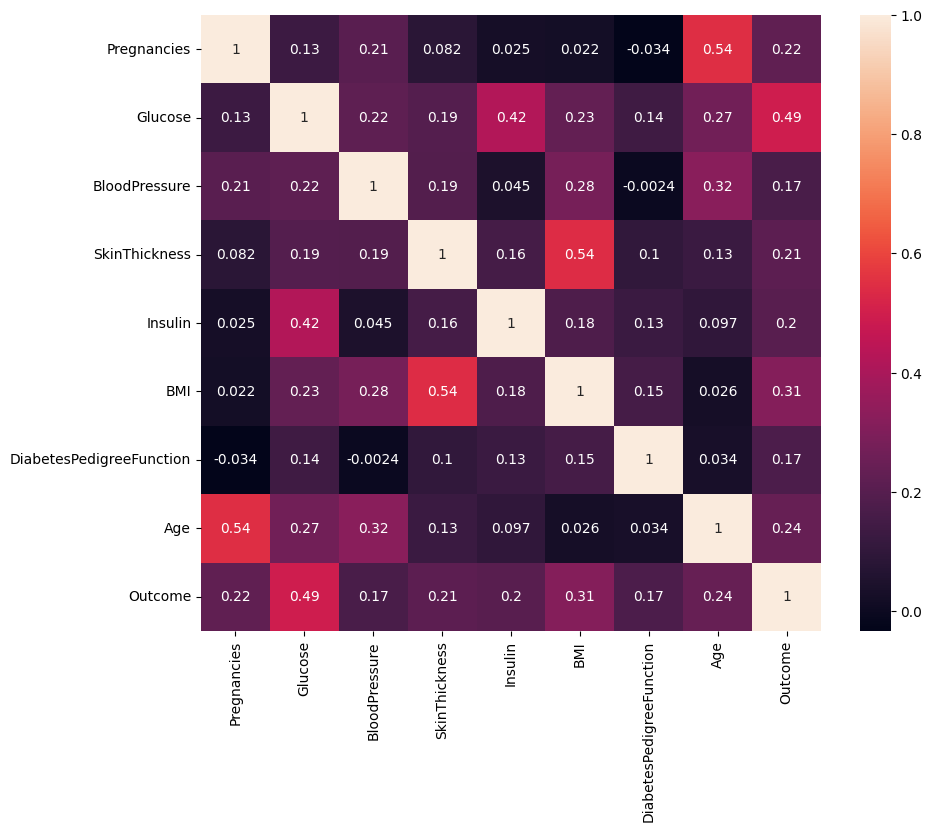

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

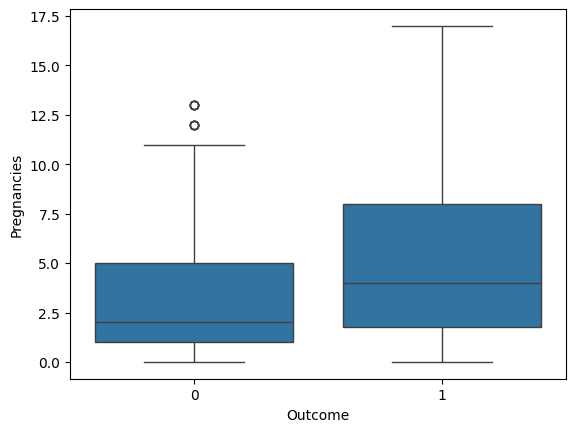

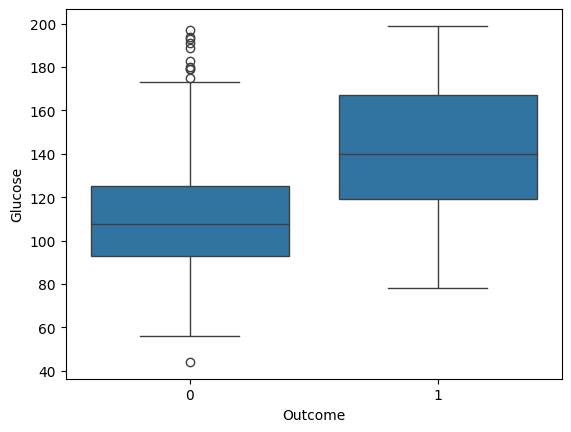

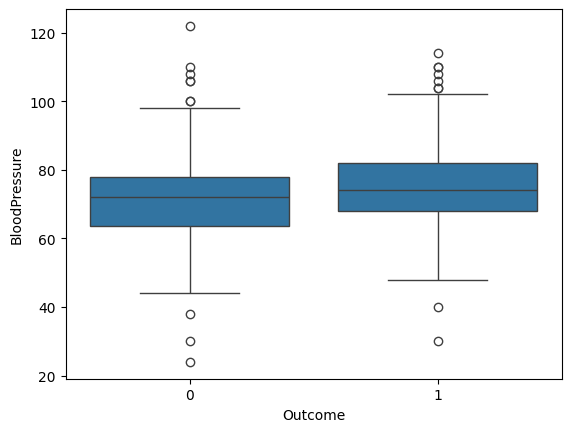

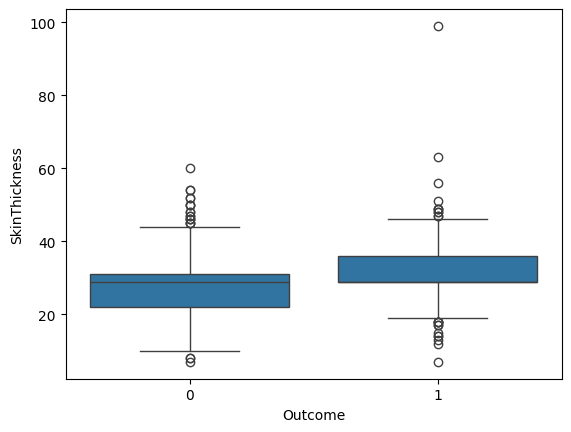

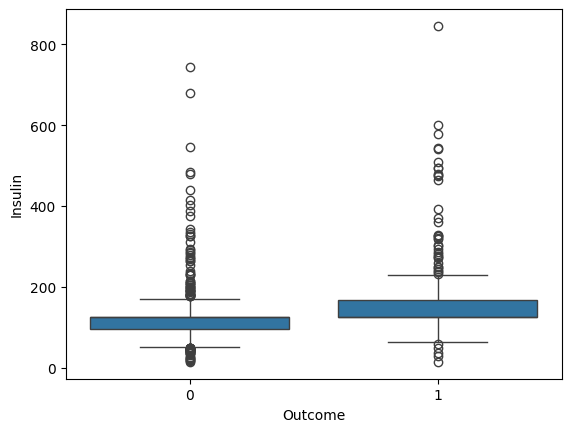

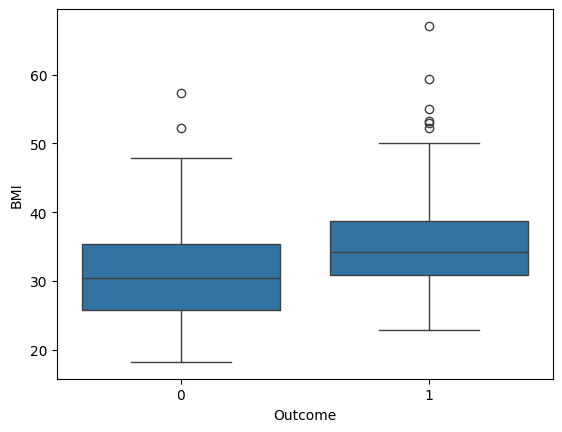

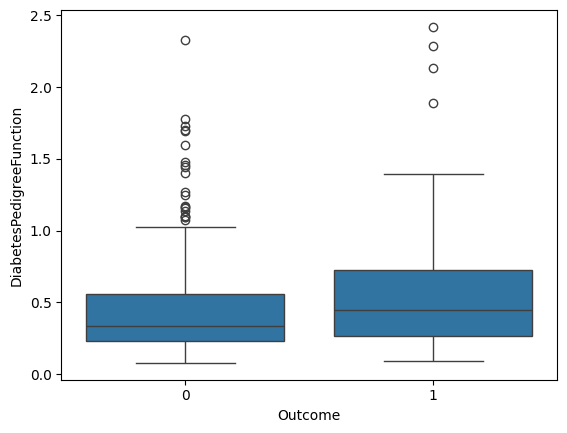

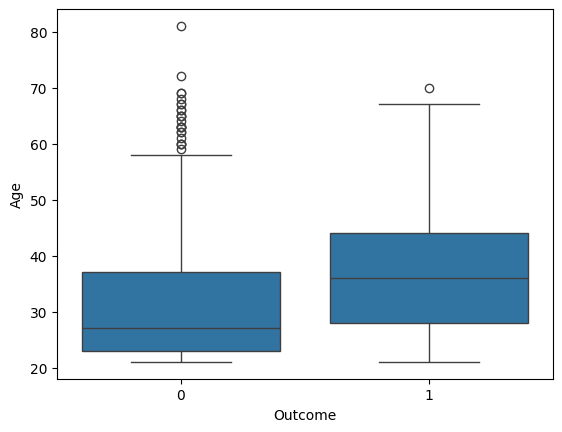

In [17]:
for col in df.columns[:-1]:
    sns.boxplot(x='Outcome', y=col, data=df)
    plt.show()

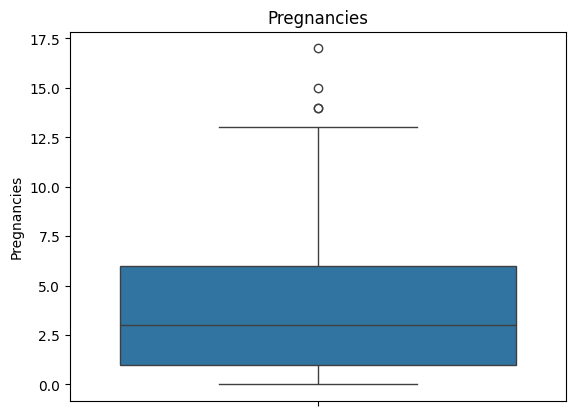

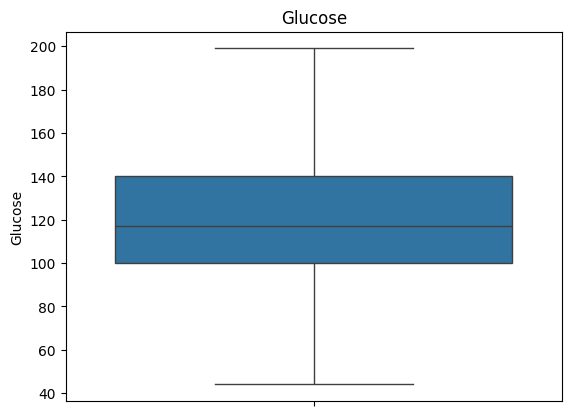

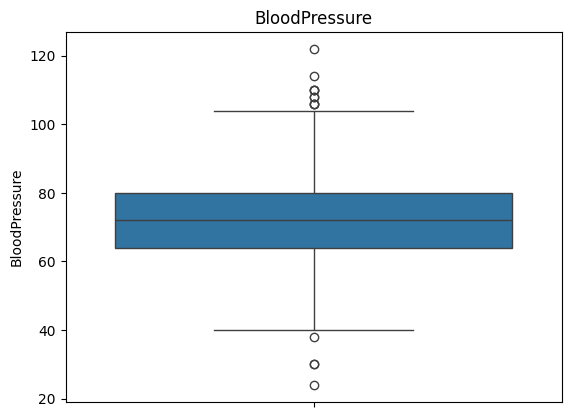

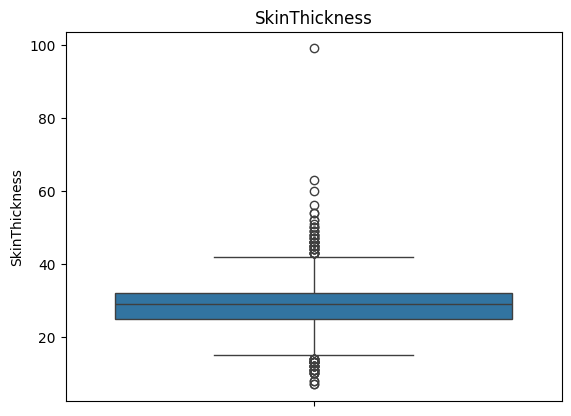

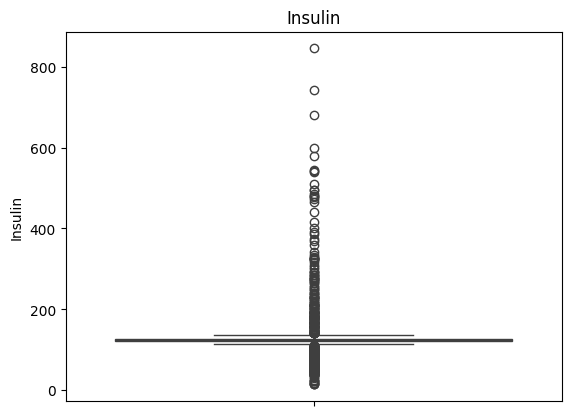

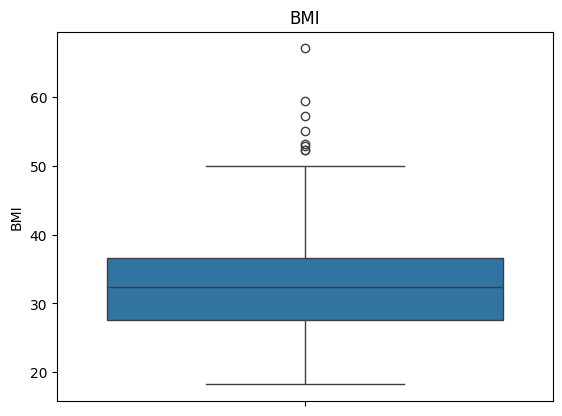

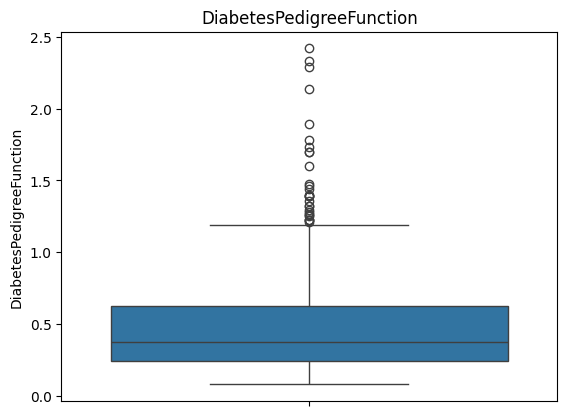

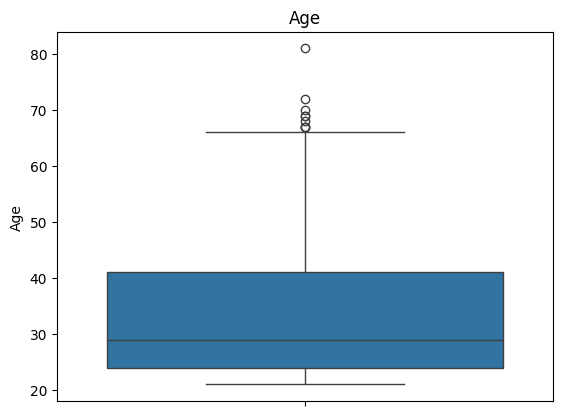

In [18]:
for col in df.columns[:-1]:
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.show()

In [19]:
df['Outcome'].value_counts(normalize=True)*100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

In [20]:
df.corr()['Outcome'].sort_values()

BloodPressure               0.165723
DiabetesPedigreeFunction    0.173844
Insulin                     0.203790
SkinThickness               0.214873
Pregnancies                 0.221898
Age                         0.238356
BMI                         0.312038
Glucose                     0.492782
Outcome                     1.000000
Name: Outcome, dtype: float64

In [21]:
df.head(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [23]:
x = df.iloc[:,:-1]
y = df['Outcome']

In [24]:
x_train,x_test, y_train,y_test = train_test_split(x,y, test_size=0.25, random_state=42)

In [25]:
scaler = StandardScaler()

In [26]:
scaled_x_train = scaler.fit_transform(x_train)
scaled_x_test = scaler.transform((x_test))

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
logistic_modal = LogisticRegression()

In [29]:
logistic_modal.fit(scaled_x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
from sklearn.metrics import accuracy_score, classification_report

In [31]:
y_train_predict = logistic_modal.predict(scaled_x_train)
y_test_predict = logistic_modal.predict(scaled_x_test)

In [32]:
print("train accuracy score: ", accuracy_score(y_train, y_train_predict))
print("test accuracy score: ", accuracy_score(y_test, y_test_predict))

train accuracy score:  0.7829861111111112
test accuracy score:  0.7395833333333334


In [34]:
print("train classification report: ")
print(classification_report(y_train, y_train_predict))
print("test classification report: ")
print(classification_report(y_test, y_test_predict))

train classification report: 
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       377
           1       0.74      0.58      0.65       199

    accuracy                           0.78       576
   macro avg       0.77      0.73      0.75       576
weighted avg       0.78      0.78      0.78       576

test classification report: 
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       123
           1       0.65      0.61      0.63        69

    accuracy                           0.74       192
   macro avg       0.72      0.71      0.71       192
weighted avg       0.74      0.74      0.74       192



In [35]:
from joblib import dump

In [36]:
dump(logistic_modal,'logistic_modal.joblib')
dump(scaler, 'scaler.joblib')

['scaler.joblib']

In [57]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [66]:
models = {
  'LogisticRegression': LogisticRegression(),
  'LogisticRegressionCV': LogisticRegressionCV(cv=5),
  'SVC': SVC(),
  'DecisionTreeClassifier': DecisionTreeClassifier(max_depth=4, min_samples_split=10, random_state=42),
  'RandomForestClassifier': RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=5, random_state=42)
}

In [67]:
from sklearn.metrics import accuracy_score

for key, values in models.items():
  model = values
  model.fit(scaled_x_train, y_train)

  y_train_predict = model.predict(scaled_x_train)
  y_test_predict = model.predict(scaled_x_test)

  print(f"---- {key} ----")
  print("Train Accuracy: ", accuracy_score(y_train, y_train_predict)*100)
  print("Test Accuracy: ", accuracy_score(y_test, y_test_predict)*100)


---- LogisticRegression ----
Train Accuracy:  78.29861111111111
Test Accuracy:  73.95833333333334
---- LogisticRegressionCV ----
Train Accuracy:  77.60416666666666
Test Accuracy:  72.39583333333334
---- SVC ----
Train Accuracy:  82.98611111111111
Test Accuracy:  73.4375
---- DecisionTreeClassifier ----
Train Accuracy:  80.03472222222221
Test Accuracy:  68.22916666666666
---- RandomForestClassifier ----
Train Accuracy:  86.28472222222221
Test Accuracy:  74.47916666666666


In [70]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

decision_model = DecisionTreeClassifier()
random_model = RandomForestClassifier(random_state=42)

decisionParams = {
    'max_depth': [3,4,5,6,7,8],
    'min_samples_split': [5,7,9,11,13,15,16,18,20],
    'random_state': [36,38,40,42,44,46,48,50]
}

randomParams = {
    'n_estimators': [100,200,300],
    'max_depth': [4,6,8,10,None],
    'min_samples_leaf': [1,3,4,5,7],
    'min_samples_split': [2,5,10]
}

decision_cv = GridSearchCV(
    estimator=decision_model,
    param_grid=decisionParams,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

random_cv = GridSearchCV(
    estimator=random_model,
    param_grid=randomParams,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

decision_cv.fit(scaled_x_train, y_train)
random_cv.fit(scaled_x_train, y_train)

decision_y_train_predict = decision_cv.predict(scaled_x_train)
decision_y_test_predict = decision_cv.predict(scaled_x_test)

random_y_train_predict = random_cv.predict(scaled_x_train)
random_y_test_predict = random_cv.predict(scaled_x_test)

print("Decision Best Params:", decision_cv.best_params_)
print("Random Best Params:", random_cv.best_params_)

print("\n---- Decision Tree ----")
print("Train Accuracy:", accuracy_score(y_train, decision_y_train_predict)*100)
print("Test Accuracy :", accuracy_score(y_test, decision_y_test_predict)*100)

print("\n---- Random Forest ----")
print("Train Accuracy:", accuracy_score(y_train, random_y_train_predict)*100)
print("Test Accuracy :", accuracy_score(y_test, random_y_test_predict)*100)

Decision Best Params: {'max_depth': 4, 'min_samples_split': 11, 'random_state': 40}
Random Best Params: {'max_depth': None, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100}

---- Decision Tree ----
Train Accuracy: 80.03472222222221
Test Accuracy : 68.22916666666666

---- Random Forest ----
Train Accuracy: 94.44444444444444
Test Accuracy : 75.52083333333334


In [47]:
logistic_modal = LogisticRegression()

In [48]:
logistic_modal.fit(scaled_x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

In [53]:
y_train_predict = logistic_modal.predict(scaled_x_train)
y_test_predict = logistic_modal.predict(scaled_x_test)

In [54]:
print("train accuracy score: ", accuracy_score(y_train, y_train_predict))
print("test accuracy score: ", accuracy_score(y_test, y_test_predict))

train accuracy score:  0.7829861111111112
test accuracy score:  0.7395833333333334


In [82]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [86]:
inputData = (1,	85.0,	66.0,	29.0,	125.0,	26.6,	0.351,	31)
test_data = np.array(inputData)
test_data = test_data.reshape(1,-1)
test_data
scaled_data = scaler.transform(test_data)
result = logistic_modal.predict(scaled_data)
print("Diabetes result is: ", result)


Diabetes result is:  [0]


c:\Administration_\machine-learning-projects\venv1\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
df.head(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0


In [13]:
x = df.drop('Outcome', axis=1)
y = df['Outcome']

In [15]:
scaler = StandardScaler()

In [46]:
x = pd.DataFrame(scaler.fit_transform(x))

In [47]:
x.head()

,0,1,2,3,4,5,6,7
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496


In [48]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [49]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y, random_state=42)

In [50]:
model = SVC(kernel='linear')

In [51]:
model.fit(x_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [52]:
y_predict = model.predict(x_test)

In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix


In [54]:
accuracy_score(y_test, y_predict)

0.7207792207792207

In [55]:
confusion_matrix(y_test, y_predict)

array([[83, 17],
       [26, 28]])

In [56]:
accuracy_score(y_train, model.predict(x_train))

0.7915309446254072